### [ 분류 실습 : Fish 데이터셋 - DecisionTree ]

**목표**
- 데이터 : fish.csv
- 품 종 : 모든 품종 Species
- 피 처 : 모든 피쳐 Weight,Length,Diagonal,Height,Width
- 학습종류 : 지도학습 - 분류
- 학습방법 : 앙상블의 보팅 => 데이터셋 동일 + 다른 여러개 모델들 학습

- 보팅의 결과 도출 방식
* 하드 보팅 : 모든 모델들의 결과에서 다수결 결정
* 소프트 보팅 : 모들 모델들의 확률 결과를 클래스별로 평균 계산해서 평균이 가장 높은 것으로 결정

    **학습설계**
- 모델 : SVC, KNeighborsClassifier, DecisionTreeClassifier=> VotingClassifier

In [1]:
## ML 전처리 관련
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import LabelEncoder

## ML 파이프라인 관련
from sklearn.pipeline import Pipeline

## ML 모델 관련
from sklearn.tree import DecisionTreeClassifier

## ML 성능지표 관련
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier

## 시각화 관련
import matplotlib.pyplot as plt
import koreanize_matplotlib
import pandas as pd

In [9]:


from sklearn.model_selection import train_test_split #학습용| 테스트용 데이터 분할
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier # 모델클래스
from sklearn.metrics import accuracy_score, classification_report # 평가
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [3]:
## 데이터 준비 
DATA_FILE= '../Data/Numbers/fish.csv'
fishDF= pd.read_csv(DATA_FILE)

In [4]:
## 데이터 기본 정보 확인
fishDF.info()
fishDF.head(2)

## 클래스 개수 및 비율
print('클래스별 데이터 개수 : ', fishDF['Species'].value_counts().to_list())
print('클래스별 데이터 개수 : ', fishDF['Species'].value_counts().to_list())
print('클래스별 데이터 비율 : ', fishDF['Species'].value_counts(normalize=True).round(1).tolist())

fishDF['Species' ]. value_counts() .index


## ---------------------------------------------------
## => 해석
## - Weight 컬럼: 최소값 0--> 몇 개 존재. 이상치
## - Species 컬럼: str --> category 형변환
##                타겟 컬럼으로 LabelEncoding 진행
##                고유값 7개 --> 다중 클래스 분류 | 불균형 데이터셋
## - 수치값 컬럼들: 값 차이 크게 남--> 스케일링 필요
## ---------------------------------------------------




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   159 non-null    object 
 1   Weight    159 non-null    float64
 2   Length    159 non-null    float64
 3   Diagonal  159 non-null    float64
 4   Height    159 non-null    float64
 5   Width     159 non-null    float64
dtypes: float64(5), object(1)
memory usage: 7.6+ KB
클래스별 데이터 개수 :  [56, 35, 20, 17, 14, 11, 6]
클래스별 데이터 개수 :  [56, 35, 20, 17, 14, 11, 6]
클래스별 데이터 비율 :  [0.4, 0.2, 0.1, 0.1, 0.1, 0.1, 0.0]


Index(['Perch', 'Bream', 'Roach', 'Pike', 'Smelt', 'Parkki', 'Whitefish'], dtype='object', name='Species')

In [5]:
X = fishDF.drop('Species', axis=1)
y = fishDF['Species']

In [45]:
# 피쳐 / 타겟 분리
X = fishDF.drop('Species', axis=1)
y = fishDF['Species']

# 학습 / 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print('전체 y 분포')
print(y.value_counts())

print('훈련 y 분포')
print(y_train.value_counts())

print('테스트 y 분포')
print(y_test.value_counts())

전체 y 분포
Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64
훈련 y 분포
Species
Perch        45
Bream        28
Roach        16
Pike         13
Smelt        11
Parkki        9
Whitefish     5
Name: count, dtype: int64
테스트 y 분포
Species
Perch        11
Bream         7
Roach         4
Pike          4
Smelt         3
Parkki        2
Whitefish     1
Name: count, dtype: int64


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=10
)

**[3] 데이터 전처리**


In [18]:
# 타겟 컬럼 인코딩
# Pipeline은 feature 처리용이므로 target 인코딩은 따로 진행
lbEncoder = LabelEncoder()

# 학습용 데이터 기준으로 인코딩
y_train_en = lbEncoder.fit_transform(y_train)

# 학습용 데이터 기준으로 테스트 데이터 변환
y_test_en = lbEncoder.transform(y_test)

# 인코더 정보 확인
print(f'classes_ : {lbEncoder.classes_}')

classes_ : ['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']


**[3] 파이프라인+ 교차 검증+ 튜닝 준비**

In [19]:

##
## 파이프라인 인스턴스 생성 : 전처리기(스케일러) + 모델
##
## => 보팅 인스턴스 생성
votsModel = VotingClassifier(estimators=[('kModel', KNeighborsClassifier()),
                                        ('svcModel', SVC(class_weight='balanced')),
                                        ("dtModel", DecisionTreeClassifier(random_state=42,
                                                                            class_weight='balanced')) ])

## => 파이프라인 인스턴스 생성
pipe = Pipeline(steps=[
                        ('rbScaler', RobustScaler()),
                        ('votModel', votsModel)
])

## 분류용 교차검증 인스턴스 생성
skFold = StratifiedKFold(shuffle=True, random_state=12)

## 하이퍼파라미터 설정 : 모델변수명_ _파라미터
## DT모델 문제 : 과대적합
params = {'votModel __ dtModel_criterion' : ['gini', 'entropy', 'log_loss'],
'votModel__kModel_n_neighbors' : [5, 7, 9, 11, 20],
'votModel__svcModel_C' : [0.1, 0.5, 1.0, 5] }

## 교차검증+튜닝 인스턴스 생성



## => 불균형 데이터셋 : 성능지표, 교차검증방식, 베스트 모델 선정 기준 - refit
tunning = GridSearchCV( pipe,
                        cv=skFold,
                        param_grid=params,
                        scoring=['f1_macro', 'f1_weighted'],
                        refit='f1_macro',
                        return_train_score=True)

tunning


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=12, shuffle=True),
             estimator=Pipeline(steps=[('rbScaler', RobustScaler()),
                                       ('votModel',
                                        VotingClassifier(estimators=[('kModel',
                                                                      KNeighborsClassifier()),
                                                                     ('svcModel',
                                                                      SVC(class_weight='balanced')),
                                                                     ('dtModel',
                                                                      DecisionTreeClassifier(class_weight='balanced',
                                                                                             random_state=42))]))]),
             param_grid={'votModel __ dtModel_criterion': ['gini', 'entropy',
                                                           'log_loss'],
                         'votModel__kModel_n_neighbors': [5, 7, 9, 11, 20],
                         'votModel__svcModel_C': [0.1, 0.5, 1.0, 5]},
             refit='f1_macro', return_train_score=True,
             scoring=['f1_macro', 'f1_weighted'])

In [20]:


# Pipe의 파라미터 확인

for key in pipe.get_params().keys():
    if 'dtModel' in key or 'kModel' in key or 'svcModel' in key:
        print(key)

votModel__kModel
votModel__svcModel
votModel__dtModel
votModel__kModel__algorithm
votModel__kModel__leaf_size
votModel__kModel__metric
votModel__kModel__metric_params
votModel__kModel__n_jobs
votModel__kModel__n_neighbors
votModel__kModel__p
votModel__kModel__weights
votModel__svcModel__C
votModel__svcModel__break_ties
votModel__svcModel__cache_size
votModel__svcModel__class_weight
votModel__svcModel__coef0
votModel__svcModel__decision_function_shape
votModel__svcModel__degree
votModel__svcModel__gamma
votModel__svcModel__kernel
votModel__svcModel__max_iter
votModel__svcModel__probability
votModel__svcModel__random_state
votModel__svcModel__shrinking
votModel__svcModel__tol
votModel__svcModel__verbose
votModel__dtModel__ccp_alpha
votModel__dtModel__class_weight
votModel__dtModel__criterion
votModel__dtModel__max_depth
votModel__dtModel__max_features
votModel__dtModel__max_leaf_nodes
votModel__dtModel__min_impurity_decrease
votModel__dtModel__min_samples_leaf
votModel__dtModel__min_samp

In [23]:
# 튜닝 학습 먼저
tunning.fit(X_train, y_train_en)

# 그 다음 최고 파라미터, 최고 점수 확인
print(f'best_params_ : {tunning.best_params_}')
print(f'best_score_  : {tunning.best_score_:.4f}')

# Pipeline 전체 베스트 모델
bestPipe = tunning.best_estimator_

# VotingClassifier 꺼내기
bestVoting = bestPipe.named_steps['votModel']

# VotingClassifier 안의 DecisionTree 모델 꺼내기
bestModel = bestVoting.named_estimators_['dtModel']

print(f'n_features_in_       : {bestModel.n_features_in_}')
print(f'feature_names        : {X_train.columns.tolist()}')
print(f'feature_importances_ : {bestModel.feature_importances_}')
print(f'classes_name         : {lbEncoder.classes_}')
print(f'classes_             : {bestModel.classes_}')
print(f'n_classes_           : {bestModel.n_classes_}')

ValueError: Invalid parameter 'votModel ' for estimator Pipeline(steps=[('rbScaler', RobustScaler()),
                ('votModel',
                 VotingClassifier(estimators=[('kModel',
                                               KNeighborsClassifier()),
                                              ('svcModel',
                                               SVC(class_weight='balanced')),
                                              ('dtModel',
                                               DecisionTreeClassifier(class_weight='balanced',
                                                                      random_state=42))]))]). Valid parameters are: ['memory', 'steps', 'transform_input', 'verbose'].

In [14]:
# 최고 파라미터, 최고 점수 확인
print(f'best_params_ : {tunning.best_params_}')
print(f'best_score_  : {tunning.best_score_:.4f}')


## => 모델 인스턴스만 저장
bestModel = tunning.best_estimator_.named_steps['votModel' ].named_estimators_['dtModel']

print(f'n_features_in_       : {bestModel.n_features_in_}')
print(f'feature_names        : {X_train.columns.tolist()}')
print(f'feature_importances_ : {bestModel.feature_importances_}')
print(f'classes_name         : {lbEncoder.classes_}')
print(f'classes_             : {bestModel.classes_}')
print(f'n_classes_           : {bestModel.n_classes_}')

AttributeError: 'GridSearchCV' object has no attribute 'best_params_'

**[6] 테스트 진행**

In [54]:
# 학습 / 테스트 데이터셋 평가
train_score = bestPipe.score(X_train, y_train_en)
test_score = bestPipe.score(X_test, y_test_en)

print(f'훈련 점수 : {train_score:.4f}')
print(f'테스트 점수 : {test_score:.4f}')

훈련 점수 : 0.8740
테스트 점수 : 0.5625


In [55]:
# 예측값 추출
y_pre = bestPipe.predict(X_test)

# 예측값 이름으로 변환
y_pre_name = lbEncoder.inverse_transform(y_pre)

print(y_pre)
print(y_pre_name)

[1 0 5 3 3 2 4 0 5 4 4 0 5 4 4 0 1 2 6 0 1 3 6 6 2 2 3 4 4 4 0 6]
['Parkki' 'Bream' 'Smelt' 'Pike' 'Pike' 'Perch' 'Roach' 'Bream' 'Smelt'
 'Roach' 'Roach' 'Bream' 'Smelt' 'Roach' 'Roach' 'Bream' 'Parkki' 'Perch'
 'Whitefish' 'Bream' 'Parkki' 'Pike' 'Whitefish' 'Whitefish' 'Perch'
 'Perch' 'Pike' 'Roach' 'Roach' 'Roach' 'Bream' 'Whitefish']


**시각화**

In [58]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd
import matplotlib.pyplot as plt

In [59]:
# 혼동행렬
condata = confusion_matrix(y_test_en, y_pre)

conDF = pd.DataFrame(
    condata,
    index=lbEncoder.classes_,
    columns=lbEncoder.classes_
)

display(conDF)

,Bream,Parkki,Perch,Pike,Roach,Smelt,Whitefish
Bream,6,1,0,0,0,0,0
Parkki,0,2,0,0,0,0,0
Perch,0,0,2,2,6,0,1
Pike,0,0,2,2,0,0,0
Roach,0,0,0,0,2,0,2
Smelt,0,0,0,0,0,3,0
Whitefish,0,0,0,0,0,0,1


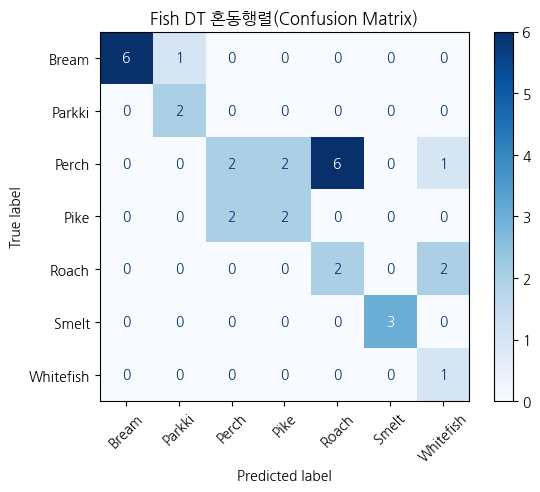

In [60]:
# 혼동행렬 시각화
disp = ConfusionMatrixDisplay(
    confusion_matrix=condata,
    display_labels=lbEncoder.classes_
)

disp.plot(cmap='Blues')
plt.title('Fish DT 혼동행렬(Confusion Matrix)')
plt.xticks(rotation=45)
plt.show()

In [61]:
# accuracy, precision, recall, f1-score 계산
accuracy = accuracy_score(y_test_en, y_pre)
precision = precision_score(y_test_en, y_pre, average='macro', zero_division=0)
recall = recall_score(y_test_en, y_pre, average='macro', zero_division=0)
f1 = f1_score(y_test_en, y_pre, average='macro', zero_division=0)

scoreDF = pd.DataFrame({
    'Metric': ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'],
    'Score': [accuracy, precision, recall, f1]
})

display(scoreDF)

,Metric,Score
0,accuracy,0.562500
1,precision_macro,0.595238
2,recall_macro,0.719852
3,f1_macro,0.603297


In [62]:
# 피쳐 중요도 확인
featureDF = pd.DataFrame({
    'feature': X_train.columns,
    'importance': bestModel.feature_importances_
}).sort_values('importance', ascending=False)

display(featureDF)

,feature,importance
3,Height,0.526654
4,Width,0.304321
2,Diagonal,0.153041
1,Length,0.015985
0,Weight,0.000000
